In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def lanczos(A_orig, p, n, k):
    V_block = np.random.rand(n, p)
    V_j, _ = np.linalg.qr(V_block) #orthonormalize
    B_j = np.zeros((p, p))
    V_prev = np.zeros((n, p))
    A_list = []
    B_list = []
    V_list = []
    m = n//p #num blocks
    stop = 0
    print(f"running for {m} iterations")
    for j in range(1, m+1):
        W = A_orig @ V_j - V_prev @ B_j.T
        A_j = V_j.T @ W
        W = W - V_j @ A_j
        V_prev = V_j
        if np.min(np.abs(np.diag(B_j))) < 1e-10 and j > 1:   # breakdown/rank-deficiency check
            print(f"Breakdown at iteration {j}, stopping.")
            stop = j - 1
            break
        V_list.append(V_j)
        B_list.append(B_j)
        A_list.append(A_j)
        V_j, B_j = np.linalg.qr(W)
    
    if stop > 0: m = stop
    T_m = np.zeros((m*p, m*p))
    for j in range(m):
        T_m[j*p:(j+1)*p, j*p:(j+1)*p] = A_list[j]
    
    for j in range(m-1):
        T_m[(j+1)*p:(j+2)*p, j*p:(j+1)*p] = B_list[j]
        T_m[j*p:(j+1)*p, (j+1)*p:(j+2)*p] = B_list[j].T

    theta, S = np.linalg.eigh(T_m) #eigen vetcors of T_m (mp, mp)
    Q_m = np.hstack(V_list) #span of lanczos basis (n, mp)
    V_hat = Q_m @ S #ritz vectors of (n, mp) shape
    Q_m = np.hstack(V_list)
    orth_error = np.linalg.norm(Q_m.T @ Q_m - np.eye(Q_m.shape[1]))
    idx = np.argsort(theta)[::-1][:k]
    lambda_k = theta[idx]
    V_k = V_hat[:, idx]
    A_approx = V_k @ np.diag(lambda_k) @ V_k.T

    return A_approx

In [23]:
#error
def one_term_error(approx, orig, non_compressed, is_left_compressed):
    #A kron B
    # use actual np.kron for clarity
    # is position dependent
    if is_left_compressed:
        res_approx = np.kron(approx, non_compressed)
        print(f"The rank of the kron prod when compressing the left mat is {np.linalg.matrix_rank(res_approx)}")
        print(f"left matrix rank: {np.linalg.matrix_rank(approx)}, right matrix rank: {np.linalg.matrix_rank(non_compressed)}")
        res_actual = np.kron(orig, non_compressed)
        kron_abs_error = np.linalg.norm(res_approx - res_actual, 'fro')
        kron_rel_error = kron_abs_error / np.linalg.norm(res_actual, 'fro')
    else:
        res_approx = np.kron(non_compressed, approx)
        print(f"The rank of the kron prod when compressing the right mat is {np.linalg.matrix_rank(res_approx)}")
        print(f"left matrix rank: {np.linalg.matrix_rank(non_compressed)}, right matrix rank: {np.linalg.matrix_rank(approx)}")
        res_actual = np.kron(non_compressed, orig)
        kron_abs_error = np.linalg.norm(res_approx - res_actual, 'fro')
        kron_rel_error = kron_abs_error / np.linalg.norm(res_actual, 'fro')
    return (kron_abs_error, kron_rel_error)

def two_term_error(A_approx, A_orig, B_approx, B_orig):
    res_actual = np.kron(A_orig, B_orig)
    res_approx = np.kron(A_approx, B_approx)
    print(f"The rank of the kron prod when compressing both mat is {np.linalg.matrix_rank(res_approx)}")
    print(f"left matrix rank: {np.linalg.matrix_rank(A_approx)}, right matrix rank: {np.linalg.matrix_rank(B_approx)}")
    kron_abs_error = np.linalg.norm(res_approx-res_actual, 'fro')
    kron_rel_error = kron_abs_error / np.linalg.norm(res_actual, 'fro')
    return (kron_abs_error, kron_rel_error)

In [21]:
def one_term_low_rank_exp(left, right, p, k):
    left_errs = [] #struct errors
    right_errs = [] #scalar errors
    for p_i, k_i in zip(p, k):
        left_approx = lanczos(left, p_i, left.shape[0], k_i)
        left_errs.append(one_term_error(left_approx, left, right, True))
        right_approx = lanczos(right, p_i, right.shape[0], k_i)
        right_errs.append(one_term_error(right_approx, right, left, False))
    return right_errs, left_errs

def two_term_low_rank_exp(A, B, p, k):
    errs = []
    for p_i, k_i in zip(p, k):
        B_approx = lanczos(B, p_i, B.shape[0], k_i)
        A_approx = lanczos(A, p_i, A.shape[0], k_i)
        errs.append(two_term_error(A_approx, A, B_approx, B))
    return errs

In [24]:
#making left operand smaller in  A kron B
left_mat = np.random.rand(10,10)
left_mat = left_mat + left_mat.T

k_small = [1, 2, 3, 4]
p_small = [i + 6 for i in k_small]

right_mat = np.random.rand(50, 50)
right_
right_errs_small, left_errs_small = one_term_low_rank_exp(left_mat, right_mat, p_small, k_small)
errs_small = two_term_low_rank_exp(left_mat, right_mat, p_small, k_small)

running for 1 iterations
The rank of the kron prod when compressing the left mat is 50
left matrix rank: 1, right matrix rank: 50
running for 7 iterations
The rank of the kron prod when compressing the right mat is 10
left matrix rank: 10, right matrix rank: 1
running for 1 iterations
The rank of the kron prod when compressing the left mat is 100
left matrix rank: 2, right matrix rank: 50
running for 6 iterations
The rank of the kron prod when compressing the right mat is 20
left matrix rank: 10, right matrix rank: 2
running for 1 iterations
The rank of the kron prod when compressing the left mat is 150
left matrix rank: 3, right matrix rank: 50
running for 5 iterations
The rank of the kron prod when compressing the right mat is 30
left matrix rank: 10, right matrix rank: 3
running for 1 iterations
The rank of the kron prod when compressing the left mat is 200
left matrix rank: 4, right matrix rank: 50
running for 5 iterations
The rank of the kron prod when compressing the right mat is

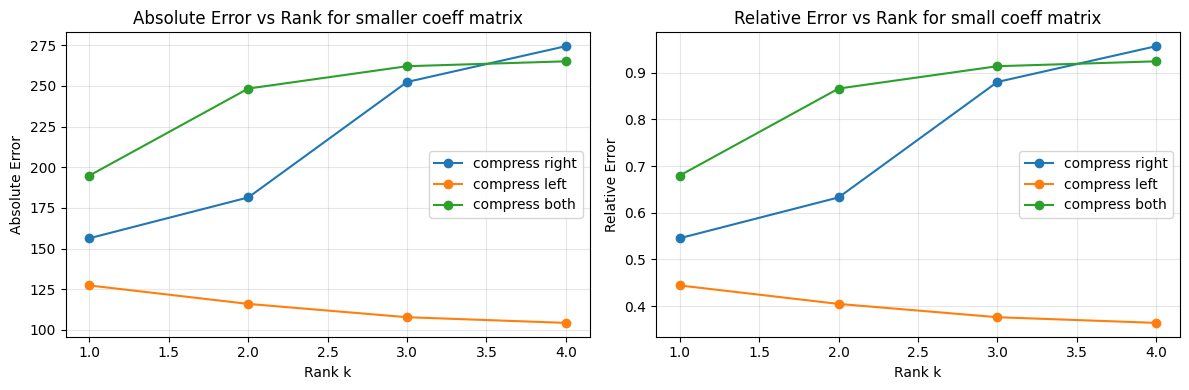

In [25]:
num_ranks = len(k_small)
fig, axes = plt.subplots(1, 2, figsize=(12, num_ranks))

labels_small = ['compress right', 'compress left', 'compress both']
series_list_small = [right_errs_small, left_errs_small, errs_small]
for series, label in zip(series_list_small, labels_small):
    abs_errors = [t[0] for t in series]
    axes[0].plot(k_small, abs_errors, marker='o', label=label)

axes[0].set_xlabel('Rank k')
axes[0].set_ylabel('Absolute Error')
axes[0].set_title('Absolute Error vs Rank for smaller coeff matrix')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
 

# Right plot: absolute error vs rank
for series, label in zip(series_list_small, labels_small):
    rel_errors = [t[1] for t in series]
    axes[1].plot(k_small, rel_errors, marker='o', label=label)

axes[1].set_xlabel('Rank k')
axes[1].set_ylabel('Relative Error')
axes[1].set_title('Relative Error vs Rank for small coeff matrix')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()